#Пет проект: UNet для бинарной сегментации

Простенькая реализация U-Net на PyTorch. Учусь делать семантическую сегментацию

Датасет: 974 изображения + маски (бинарные, значения {0, 255}).

##Импорты и конфиг

Всё, что настраивается - в одном месте (класс `Config`). Сразу фиксируем seed для воспроизводимости.

In [7]:
import os
import random
import sys
import zipfile
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split, Subset
from torch.optim.lr_scheduler import CosineAnnealingLR
from PIL import Image, ImageEnhance
from pathlib import Path
from dataclasses import dataclass, field
import matplotlib.pyplot as plt
from tqdm import tqdm

import albumentations as A
from albumentations.pytorch import ToTensorV2


def find_project_root():
  # ищем вверх папку с маркерами проекта
  cwd = Path.cwd().resolve()
  for parent in [cwd, *cwd.parents]:
    if (parent / "requirements.txt").exists() or (parent / "archive.zip").exists():
      return parent

  if "google.colab" in sys.modules and Path("/content").exists():
    return Path("/content")

  return cwd


@dataclass
class Config:
  # пути
  project_root: Path = field(default_factory=find_project_root)
  archive_name: str = "archive.zip"
  data_subdir: str = "segment"
  checkpoints_dir_name: str = "checkpoints"
  results_dir_name: str = "results"

  # данные
  img_size: int = 256
  batch_size: int = 8
  val_fraction: float = 0.15
  test_fraction: float = 0.10
  num_workers: int = 0
  augment: bool = True

  # обучение
  num_epochs: int = 50
  lr: float = 1e-3
  weight_decay: float = 1e-4
  seed: int = 42

  # сохранение
  save_name: str = "best_unet.pth"

  # вычисляемые пути
  @property
  def archive_path(self):
    return self.project_root / self.archive_name

  @property
  def data_dir(self):
    return self.project_root / "data" / self.data_subdir

  @property
  def checkpoints_dir(self):
    return self.project_root / self.checkpoints_dir_name

  @property
  def results_dir(self):
    return self.project_root / self.results_dir_name

  @property
  def save_path(self):
    return self.checkpoints_dir / self.save_name

  def prepare_dirs(self):
    self.data_dir.mkdir(parents=True, exist_ok=True)
    self.checkpoints_dir.mkdir(parents=True, exist_ok=True)
    self.results_dir.mkdir(parents=True, exist_ok=True)


def set_seed(seed):
  random.seed(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)
  torch.cuda.manual_seed_all(seed)
  torch.backends.cudnn.deterministic = True
  torch.backends.cudnn.benchmark = False


cfg = Config()
cfg.prepare_dirs()
set_seed(cfg.seed)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Project root: {cfg.project_root}")
print(f"Data dir:     {cfg.data_dir}")
print(f"Seed:         {cfg.seed}")
print(f"Device:       {DEVICE}")
print(f"Workers:      {cfg.num_workers}")

Project root: C:\Users\pavel\PycharmProjects\1\binary-face-segmentation-unet
Data dir:     C:\Users\pavel\PycharmProjects\1\binary-face-segmentation-unet\data\segment
Seed:         42
Device:       cpu
Workers:      0


## Загрузка и проверка данных

Распакуем архив (если ещё не распакован) и убедимся, что каждой jpg-картинке соответствует png-маска с тем же stem

In [8]:
def get_train_transform(img_size=256):
  return A.Compose([
      A.Resize(img_size, img_size),

      # геометрические - к картинке и маске
      A.HorizontalFlip(p=0.5),
      A.VerticalFlip(p=0.1),
      A.ShiftScaleRotate(
          shift_limit=0.05,
          scale_limit=0.10,
          rotate_limit=15,
          border_mode=0,
          p=0.4,
      ),

      # цветовые - к картинке
      A.RandomBrightnessContrast(
          brightness_limit=0.15,
          contrast_limit=0.15,
          p=0.4,
      ),
      A.HueSaturationValue(
          hue_shift_limit=10,
          sat_shift_limit=15,
          val_shift_limit=10,
          p=0.3,
      ),

      # регуляризация - к картинке
      A.CoarseDropout(
          num_holes_range=(1, 4),
          hole_height_range=(8, 24),
          hole_width_range=(8, 24),
          fill=0,
          p=0.2,
      ),

      # нормализация в отрезок [-1; 1]
      A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
      ToTensorV2(),
  ])


def get_eval_transform(img_size=256):
  return A.Compose([
      A.Resize(img_size, img_size),
      A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
      ToTensorV2(),
  ])

In [9]:
def dataset_is_ready(data_dir):
  data_dir = Path(data_dir)
  if not data_dir.exists():
    return False
  jpgs = list(data_dir.glob("*.jpg"))
  pngs = list(data_dir.glob("*.png"))
  return len(jpgs) > 0 and len(jpgs) == len(pngs)


def ensure_dataset(cfg):
  data_dir = Path(cfg.data_dir)
  archive_path = Path(cfg.archive_path)

  if dataset_is_ready(data_dir):
    n = len(list(data_dir.glob("*.jpg")))
    print(f"Данные уже на месте: {data_dir} ({n} пар)")
    return

  if not archive_path.exists():
    raise FileNotFoundError(
        f"Нет ни данных ({data_dir}), ни архива ({archive_path})."
    )

  data_dir.parent.mkdir(parents=True, exist_ok=True)

  with zipfile.ZipFile(archive_path, "r") as zip_ref:
    names = zip_ref.namelist()
    has_segment_root = any(n.startswith("segment/") for n in names)
    extract_to = data_dir.parent if has_segment_root else data_dir
    extract_to.mkdir(parents=True, exist_ok=True)
    zip_ref.extractall(extract_to)

  print(f"Архив распакован в {extract_to}")


ensure_dataset(cfg)

Архив распакован в C:\Users\pavel\PycharmProjects\1\binary-face-segmentation-unet\data


Проверим файлы

In [ ]:
files = os.listdir(cfg.data_dir)
print(f"Файлов: {len(files)}")

jpg_files = sorted([f for f in files if f.endswith(".jpg")])
png_files = sorted([f for f in files if f.endswith(".png")])
print(f"JPG: {len(jpg_files)} | PNG: {len(png_files)}")

# Проверим, что каждому jpg соответствует png с тем же stem
for j, p in zip(jpg_files, png_files):
  if Path(j).stem != Path(p).stem:
    print(f"Ошибка: {j} и {p}")
    break
else:
  print("Все пары корректны")

Проверим, как выглядит картинка и маска


JPG: /content/segment/00000003.jpg
  size=(500, 350), mode=RGB
PNG: /content/segment/00000003.png
  size=(500, 350), mode=L


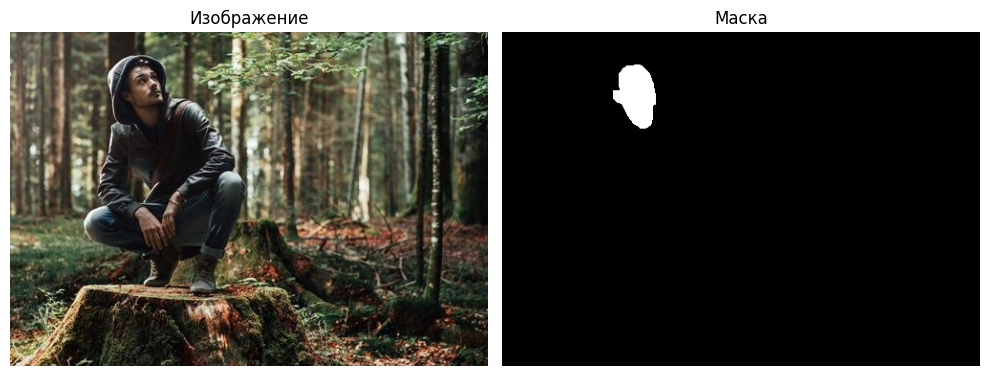

In [ ]:
sample_img_path  = os.path.join(cfg.data_dir, jpg_files[0])
sample_mask_path = os.path.join(cfg.data_dir, png_files[0])

sample_img  = Image.open(sample_img_path)
sample_mask = Image.open(sample_mask_path)

print(f"JPG: {sample_img_path}")
print(f"  size={sample_img.size}, mode={sample_img.mode}")
print(f"PNG: {sample_mask_path}")
print(f"  size={sample_mask.size}, mode={sample_mask.mode}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(sample_img);               axes[0].set_title("Изображение"); axes[0].axis("off")
axes[1].imshow(sample_mask, cmap="gray"); axes[1].set_title("Маска");       axes[1].axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# Проверим, что в маске только 2 цвета пикселей, а также форму маски

mask_array = np.array(sample_mask)
print(np.unique(mask_array))
print(mask_array.shape)

[  0 255]
(350, 500)


Составим пары файлов

In [ ]:
all_files = os.listdir(cfg.data_dir)
stems = sorted(set(Path(f).stem for f in all_files))

pairs = []
for stem in stems:
  jpg = os.path.join(cfg.data_dir, f"{stem}.jpg")
  png = os.path.join(cfg.data_dir, f"{stem}.png")
  if os.path.exists(jpg) and os.path.exists(png):
    pairs.append((jpg, png))

print(f"Пар {len(pairs)}")
print(pairs[0])

Пар 974
('/content/segment/00000003.jpg', '/content/segment/00000003.png')


Создадим класс для Датасета


In [58]:
class SegmentationDataset(Dataset):
  def __init__(self, pairs, img_size=256, augment=False):
    self.pairs = pairs
    self.img_size = img_size
    self.augment = augment
    self.transform = get_train_transform(img_size) if augment else get_eval_transform(img_size)

  def __len__(self):
    return len(self.pairs)

  def __getitem__(self, index):
    img_path, mask_path = self.pairs[index]

    img  = np.array(Image.open(img_path).convert("RGB"))
    mask = np.array(Image.open(mask_path).convert("L"))

    # маска в {0, 1}
    mask = (mask > 127).astype(np.float32)

    augmented = self.transform(image=img, mask=mask)
    img  = augmented["image"]                # уже тензор [3, H, W], нормализован в [-1, 1]
    mask = augmented["mask"].unsqueeze(0)    # [1, H, W]

    return img, mask

In [72]:
train_ds_full = SegmentationDataset(pairs, cfg.img_size, augment=True)
eval_ds_full  = SegmentationDataset(pairs, cfg.img_size, augment=False)

n_total = len(train_ds_full)
n_val   = int(cfg.val_fraction  * n_total)
n_test  = int(cfg.test_fraction * n_total)
n_train = n_total - n_val - n_test

g = torch.Generator().manual_seed(cfg.seed)
train_sub, val_sub, test_sub = random_split(
    range(n_total), [n_train, n_val, n_test], generator=g
)

train_dataset = Subset(train_ds_full, train_sub.indices)
val_dataset   = Subset(eval_ds_full,  val_sub.indices)
test_dataset  = Subset(eval_ds_full,  test_sub.indices)

train_loader = DataLoader(train_dataset, batch_size=cfg.batch_size, shuffle=True,
                          num_workers=cfg.num_workers, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=cfg.batch_size, shuffle=False,
                          num_workers=cfg.num_workers, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=cfg.batch_size, shuffle=False,
                          num_workers=cfg.num_workers, pin_memory=True)

print(f"train: {n_train} | val: {n_val} | test: {n_test}")
print(f"батчей — train: {len(train_loader)}, val: {len(val_loader)}, test: {len(test_loader)}")

train: 731 | val: 146 | test: 97
батчей — train: 92, val: 19, test: 13


In [118]:
images, masks = next(iter(train_loader))
print(f"images: {images.shape}, dtype={images.dtype}")
print(f"masks:  {masks.shape}, dtype={masks.dtype}")
print(f"уникальные в маске: {masks.unique()}")
print(f"диапазон images: [{images.min():.3f}, {images.max():.3f}]")

images: torch.Size([8, 3, 256, 256]), dtype=torch.float32
masks:  torch.Size([8, 1, 256, 256]), dtype=torch.float32
уникальные в маске: tensor([0., 1.])
диапазон images: [-1.000, 1.000]


Проверим пары изображений и масок


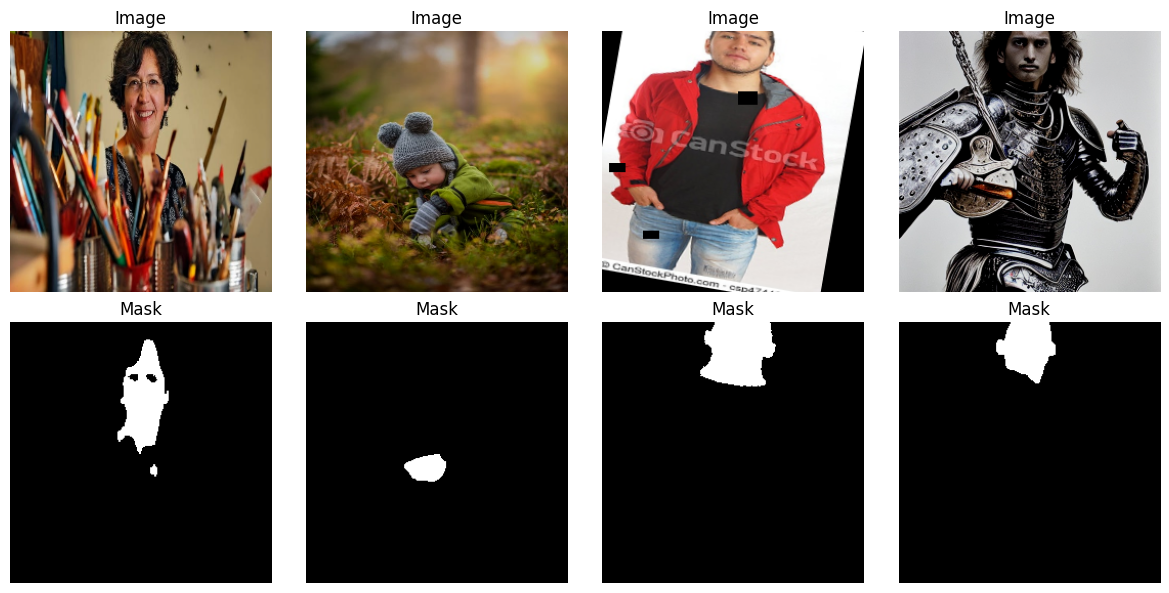

In [92]:
def denorm(x):
  return (x * 0.5 + 0.5).clamp(0, 1)


fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i in range(4):
  img  = denorm(images[i]).permute(1, 2, 0).numpy()
  mask = masks[i, 0].numpy()

  axes[0, i].imshow(img);               axes[0, i].set_title("Image"); axes[0, i].axis("off")
  axes[1, i].imshow(mask, cmap="gray"); axes[1, i].set_title("Mask");  axes[1, i].axis("off")

plt.tight_layout()
plt.show()

Проверим, что изображения и маски совпадают

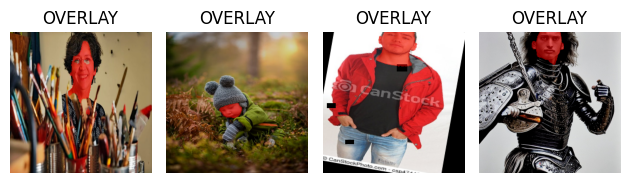

In [93]:
fig, axes = plt.subplots(1, 4)
for i in range(4):
  img = denorm(images[i]).permute(1, 2, 0).numpy()
  mask = masks[i, 0].numpy()

  overlay = img.copy()
  overlay[mask > 0.5] = overlay[mask > 0.5] * 0.5 + np.array([0.5, 0, 0])

  axes[i].imshow(overlay)
  axes[i].set_title("OVERLAY")
  axes[i].axis('off')

plt.tight_layout()
plt.show()

##UNet

Попробуем написать классический U-Net: encoder (3 блока) -> bottleneck -> decoder (3 блока со skip-connection). Выход - логиты (1 канал).




In [94]:
class EncoderBlock(nn.Module):
  def __init__(self, in_channels, out_channels):
    super().__init__()
    self.block = nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True),
    )

  def forward(self, x):
    return self.block(x)

In [95]:
class DecoderBlock(nn.Module):
  def __init__(self, in_channels, out_channels):
    super().__init__()
    self.up = nn.ConvTranspose2d(in_channels, out_channels,
                                 kernel_size=2, stride=2)
    self.block = nn.Sequential(
        nn.Conv2d(out_channels * 2, out_channels, kernel_size=3, padding=1),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True),
    )

  def forward(self, x, skip):
    x = self.up(x)
    x = torch.cat([x, skip], dim=1)
    return self.block(x)

In [96]:
class UNet(nn.Module):
  def __init__(self, in_channels=3, out_channels=1, features=(64, 128, 256, 512)):
    super().__init__()
    self.encoder1 = EncoderBlock(in_channels, features[0])
    self.encoder2 = EncoderBlock(features[0], features[1])
    self.encoder3 = EncoderBlock(features[1], features[2])

    self.pool = nn.MaxPool2d(2)

    self.bottle_neck = EncoderBlock(features[2], features[3])

    self.decoder3 = DecoderBlock(features[3], features[2])
    self.decoder2 = DecoderBlock(features[2], features[1])
    self.decoder1 = DecoderBlock(features[1], features[0])

    self.final = nn.Conv2d(features[0], out_channels, kernel_size=1)

  def forward(self, x):
    encoder1 = self.encoder1(x)
    encoder2 = self.encoder2(self.pool(encoder1))
    encoder3 = self.encoder3(self.pool(encoder2))

    b = self.bottle_neck(self.pool(encoder3))

    decoder3 = self.decoder3(b, encoder3)
    decoder2 = self.decoder2(decoder3, encoder2)
    decoder1 = self.decoder1(decoder2, encoder1)

    return self.final(decoder1)

In [97]:
model = UNet(in_channels=3, out_channels=1).to(DEVICE)

dummy = torch.randn(2, 3, cfg.img_size, cfg.img_size).to(DEVICE)
with torch.no_grad():
  out = model(dummy)

print(dummy.shape, out.shape, sum([p.numel() for p in model.parameters()]))

torch.Size([2, 3, 256, 256]) torch.Size([2, 1, 256, 256]) 7702977


##Лоссы и метрика

- **BCEDiceLoss** - стандартная связка для бинарной сегментации (0.5/0.5).
- **compute_iou** - основная метрика качества.

In [98]:
class DiceLoss(nn.Module):
  def __init__(self, smooth=1e-6):
    super().__init__()
    self.smooth = smooth

  def forward(self, preds, targets):
    preds = torch.sigmoid(preds)

    preds   = preds.view(preds.size(0), -1)
    targets = targets.view(targets.size(0), -1)

    intersection = (preds * targets).sum(dim=1)
    union        = preds.sum(dim=1) + targets.sum(dim=1)

    dice = (2 * intersection + self.smooth) / (union + self.smooth)
    return 1 - dice.mean()

In [99]:
class BCEDiceLoss(nn.Module):
  def __init__(self, bce_weight=0.5):
    super().__init__()
    self.bce = nn.BCEWithLogitsLoss()
    self.dice = DiceLoss()
    self.bce_weight = bce_weight

  def forward(self, preds, targets):
    bce_loss  = self.bce(preds, targets)
    dice_loss = self.dice(preds, targets)
    return self.bce_weight * bce_loss + (1 - self.bce_weight) * dice_loss

In [100]:
@torch.no_grad()
def compute_iou(preds, targets, threshold=0.5):
  preds = torch.sigmoid(preds)
  preds = (preds > threshold).float()

  preds   = preds.view(preds.size(0), -1)
  targets = targets.view(targets.size(0), -1)

  intersection = (preds * targets).sum(dim=1)
  union        = preds.sum(dim=1) + targets.sum(dim=1) - intersection

  iou = (intersection + 1e-6) / (union + 1e-6)
  return iou.mean().item()

In [101]:
model = UNet().to(DEVICE)
criterion = BCEDiceLoss().to(DEVICE)

dummy_preds   = torch.randn(2, 1, cfg.img_size, cfg.img_size).to(DEVICE)
dummy_targets = (torch.randn(2, 1, cfg.img_size, cfg.img_size) > 0.5).float().to(DEVICE)

loss = criterion(dummy_preds, dummy_targets)
iou  = compute_iou(dummy_preds, dummy_targets)

print(f"loss: {loss.item():.4f}")
print(f"iou:  {iou:.4f}")

loss: 0.7127
iou:  0.2353


## Обучение

Adam + CosineAnnealingLR + weight_decay. Сохраняем лучший чекпоинт по val IoU (модель + оптимизатор + метрики).

In [102]:
model = UNet().to(DEVICE)
criterion = BCEDiceLoss().to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
scheduler = CosineAnnealingLR(optimizer, T_max=cfg.num_epochs)

In [103]:
def train_one_epoch(model, loader, criterion, optimizer, device):
  model.train()
  running_loss = 0.0
  running_iou  = 0.0

  pbar = tqdm(loader, desc="train", leave=False)
  for images, masks in pbar:
    images = images.to(device, non_blocking=True)
    masks  = masks.to(device, non_blocking=True)

    optimizer.zero_grad()
    preds = model(images)
    loss  = criterion(preds, masks)
    loss.backward()
    optimizer.step()

    running_loss += loss.item()
    running_iou  += compute_iou(preds, masks)

    pbar.set_postfix(loss=f"{loss.item():.4f}")

  return running_loss / len(loader), running_iou / len(loader)


@torch.no_grad()
def validate(model, loader, criterion, device):
  model.eval()
  running_loss = 0.0
  running_iou  = 0.0

  for images, masks in loader:
    images = images.to(device, non_blocking=True)
    masks  = masks.to(device, non_blocking=True)

    preds = model(images)
    loss  = criterion(preds, masks)

    running_loss += loss.item()
    running_iou  += compute_iou(preds, masks)

  return running_loss / len(loader), running_iou / len(loader)

In [104]:
history = { "train_loss": [], "train_iou": [], "val_loss":   [], "val_iou":   [],}

best_val_iou = 0.0

for epoch in range(cfg.num_epochs):
  train_loss, train_iou = train_one_epoch(model, train_loader, criterion,
                                          optimizer, DEVICE)
  val_loss, val_iou = validate(model, val_loader, criterion, DEVICE)
  scheduler.step()

  history["train_loss"].append(train_loss)
  history["train_iou"].append(train_iou)
  history["val_loss"].append(val_loss)
  history["val_iou"].append(val_iou)

  if val_iou > best_val_iou:
    best_val_iou = val_iou
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "val_iou": best_val_iou,
    }, cfg.save_path)

  print(f"Epoch {epoch + 1:2d}/{cfg.num_epochs} | "
        f"train_loss: {train_loss:.4f} iou: {train_iou:.4f} | "
        f"val_loss: {val_loss:.4f} iou: {val_iou:.4f}")

print(f"\nЛучший val IoU: {best_val_iou:.4f}")

Epoch  1/50 | train_loss: 0.5645 iou: 0.1927 | val_loss: 0.4690 iou: 0.2878


Epoch  2/50 | train_loss: 0.4577 iou: 0.2528 | val_loss: 0.4147 iou: 0.3026


Epoch  3/50 | train_loss: 0.4082 iou: 0.2872 | val_loss: 0.3809 iou: 0.3481


Epoch  4/50 | train_loss: 0.3547 iou: 0.3529 | val_loss: 0.4128 iou: 0.2151


Epoch  5/50 | train_loss: 0.3166 iou: 0.4083 | val_loss: 0.2886 iou: 0.4363


...

Epoch 46/50 | train_loss: 0.1257 iou: 0.7387 | val_loss: 0.1372 iou: 0.7133


Epoch 47/50 | train_loss: 0.1274 iou: 0.7383 | val_loss: 0.1358 iou: 0.7169


Epoch 48/50 | train_loss: 0.1301 iou: 0.7315 | val_loss: 0.1361 iou: 0.7163


Epoch 49/50 | train_loss: 0.1239 iou: 0.7442 | val_loss: 0.1371 iou: 0.7136


Epoch 50/50 | train_loss: 0.1282 iou: 0.7351 | val_loss: 0.1363 iou: 0.7168

Лучший val IoU: 0.7176


Построим графики обучения - loss и IoU по эпохам.

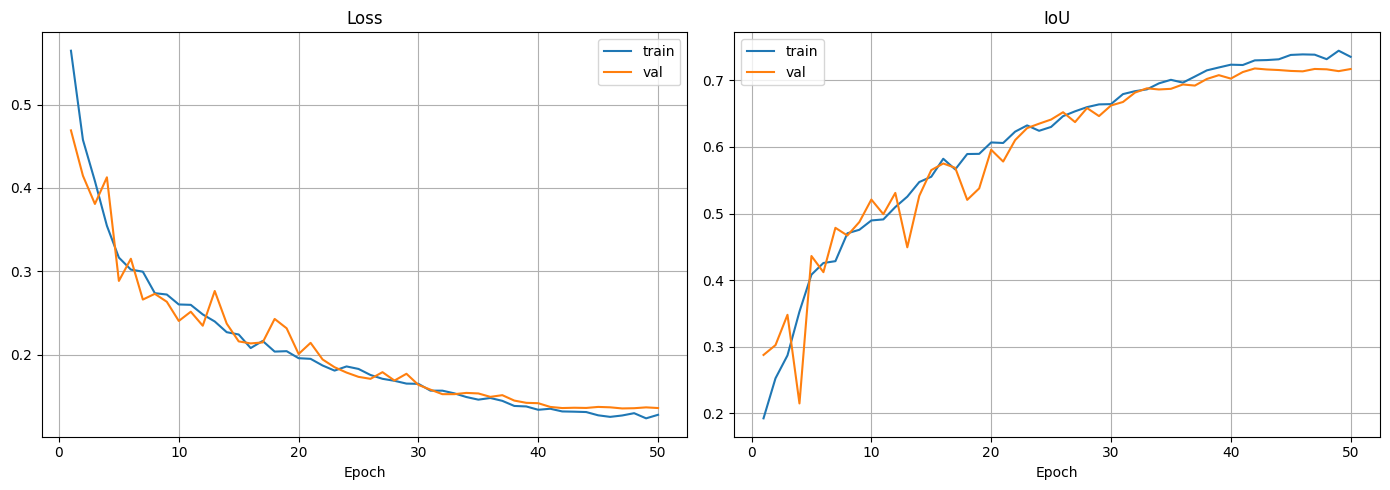

In [106]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs = range(1, len(history["train_loss"]) + 1)

axes[0].plot(epochs, history["train_loss"], label="train")
axes[0].plot(epochs, history["val_loss"],   label="val")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend(); axes[0].grid(True)

axes[1].plot(epochs, history["train_iou"], label="train")
axes[1].plot(epochs, history["val_iou"],   label="val")
axes[1].set_title("IoU");  axes[1].set_xlabel("Epoch"); axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()

##Оценка на тесте

Загружаем лучший чекпоинт и считаем метрики на тестовой выборке, которую ни разу не показывали модели.

In [109]:
checkpoint = torch.load(cfg.save_path, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
print(f"Загружен чекпоинт с эпохи {checkpoint['epoch'] + 1} (val IoU = {checkpoint['val_iou']:.4f})")

test_loss, test_iou = validate(model, test_loader, criterion, DEVICE)

print(f"\nTEST:")
print(f"  loss: {test_loss:.4f}")
print(f"  IoU:  {test_iou:.4f}")

Загружен чекпоинт с эпохи 42 (val IoU = 0.7176)

TEST:
  loss: 0.1684
  IoU:  0.6679


##Визуализация предсказаний

Посмотрим глазами, где модель ошибается: посередине - маска, справа - предсказание.

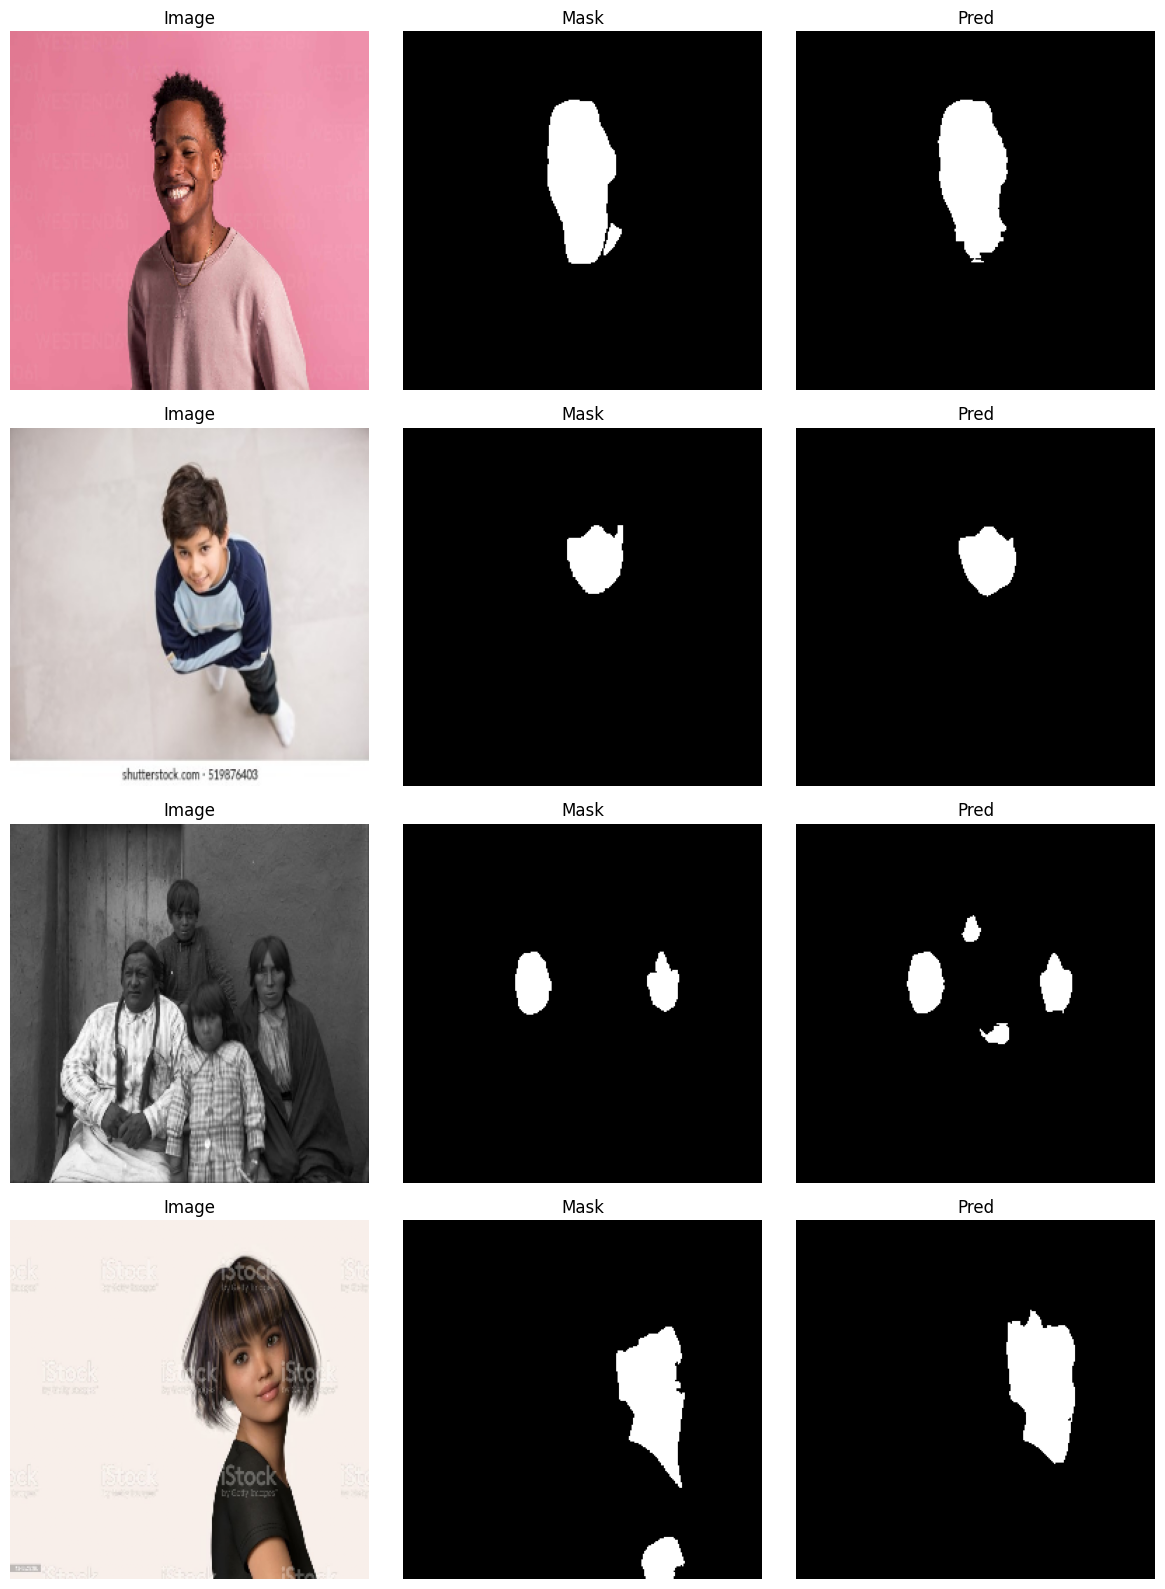

In [115]:
@torch.no_grad()
def visualize_predictions(model, loader, device, num_samples=4):
  model.eval()
  images, masks = next(iter(loader))
  images = images.to(device)
  preds  = torch.sigmoid(model(images)) > 0.5

  images, masks, preds = images.cpu(), masks.cpu(), preds.cpu()

  fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4 * num_samples))
  for i in range(num_samples):
    img = denorm(images[i]).permute(1, 2, 0).numpy()
    axes[i, 0].imshow(img);                            axes[i, 0].set_title("Image")
    axes[i, 1].imshow(masks[i, 0], cmap="gray");       axes[i, 1].set_title("Mask")
    axes[i, 2].imshow(preds[i, 0].float(), cmap="gray"); axes[i, 2].set_title("Pred")
    for ax in axes[i]:
      ax.axis("off")

  plt.tight_layout()
  plt.show()


visualize_predictions(model, test_loader, DEVICE, num_samples=4)

##Инференс одной картинки

Функция `predict` - для быстрого прогона модели на произвольном файле.

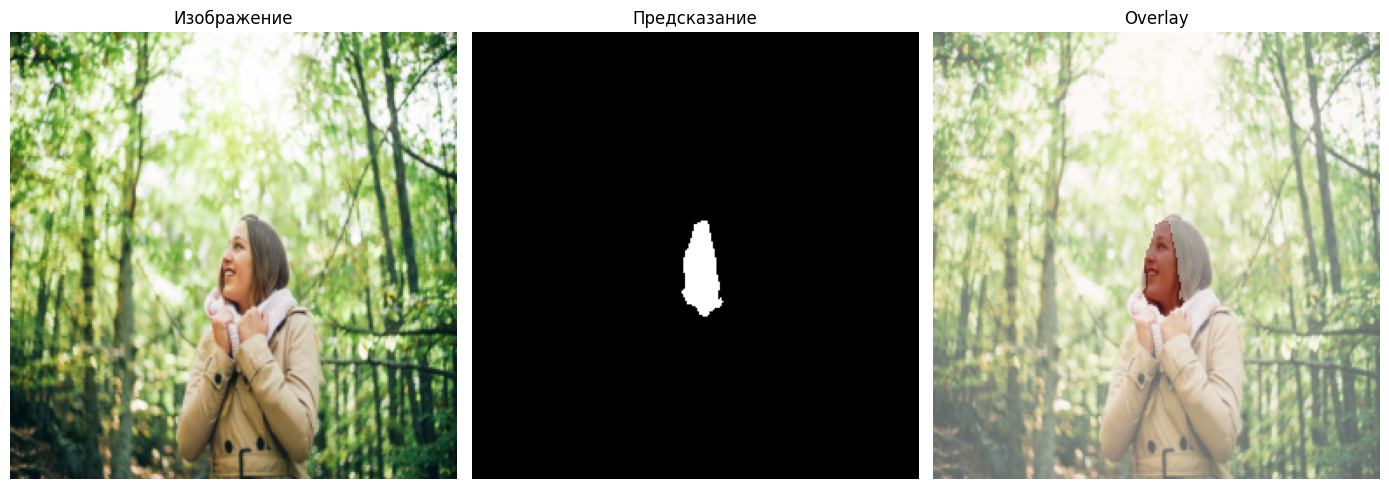

In [120]:
@torch.no_grad()
def predict(model, img_path, img_size=256, device="cuda", threshold=0.5):
  model.eval()

  img = Image.open(img_path).convert("RGB")
  img_resized = img.resize((img_size, img_size), Image.BILINEAR)

  x = np.array(img_resized, dtype=np.float32) / 255.0
  x = (x - 0.5) / 0.5
  x = torch.from_numpy(x).permute(2, 0, 1).unsqueeze(0).to(device)

  prob = torch.sigmoid(model(x))[0, 0].cpu().numpy()
  mask = (prob > threshold).astype(np.uint8) * 255

  return img_resized, mask


img_path = os.path.join(cfg.data_dir, jpg_files[77])
img, pred_mask = predict(model, img_path, cfg.img_size, DEVICE)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].imshow(img);                                        axes[0].set_title("Изображение")
axes[1].imshow(pred_mask, cmap="gray");                     axes[1].set_title("Предсказание")
axes[2].imshow(img); axes[2].imshow(pred_mask, cmap="Reds", alpha=0.4); axes[2].set_title("Overlay")
for ax in axes: ax.axis("off")
plt.tight_layout()
plt.show()